In [2]:
import sys
from pathlib import Path

# Make project root (the folder that contains `src`) importable
project_root = Path().resolve().parent  # this should be R-learner-LTE
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

import logging
from typing import Tuple

import hydra
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from omegaconf import DictConfig, OmegaConf

from src.data.base_dataset import TwoSampleDataSplit, GroundTruth
from src.data.semi_synthetic import IST3SemiSyntheticDataset
from src.data.utils import split_two_sample_data
from src.model.t_learner import TLearner
from src.model.t_r_learner import tRlearner

logging.basicConfig(level=logging.INFO)
logger = logging.getLogger(__name__)

In [3]:
def load_config(
    dataset: str | None = None,
    model: str | None = None,
    trainer: str | None = None,
    config_root: Path = Path("config"),
):
    """
    Load full config, optionally overriding dataset/model/trainer from config.yaml defaults.
    """
    base_cfg = OmegaConf.load(config_root / "config.yaml")
    defaults = base_cfg.get("defaults", [])

    def _get_default(name: str) -> str | None:
        for item in defaults:
            if isinstance(item, dict) and name in item:
                return item[name]
        return None

    dataset_name = dataset or _get_default("dataset")
    model_name = model or _get_default("model")
    trainer_name = trainer or _get_default("trainer")

    cfg = OmegaConf.create()
    cfg.dataset = OmegaConf.load(config_root / "dataset" / f"{dataset_name}.yaml")
    cfg.model = OmegaConf.load(config_root / "model" / f"{model_name}.yaml")
    cfg.trainer = OmegaConf.load(config_root / "trainer" / f"{trainer_name}.yaml")

    # copy other top-level fields (e.g. seed)
    for key, value in base_cfg.items():
        if key != "defaults":
            cfg[key] = value

    return cfg

In [4]:
config_root = 'C:\\Users\\ma\\Research\\Long-term-effects\\R-learner-LTE\\config'
cfg = load_config(dataset="semi-synthetic", model="R-learner", trainer="default", config_root=Path(config_root))

In [5]:
ist = IST3SemiSyntheticDataset(cfg.dataset)
data, gt = ist.sample()

INFO:src.data.semi_synthetic:Loaded real data from C:\Users\ma\Research\Long-term-effects\R-learner-LTE\src\data\semi_synthetic_real_data.csv with shape (2720, 32)
INFO:src.data.semi_synthetic:Numerical Columns: ['age', 'randdelay', 'sbprand', 'dbprand', 'weight', 'glucose', 'gcs_score_rand', 'nihss', 'R_infarct_size', 'R_hypodensity', 'R_swelling']
INFO:src.data.semi_synthetic:Categorical Columns: ['gender', 'country', 'livealone_rand', 'indepinadl_rand', 'atrialfib_rand', 'stroke_pre', 'hypertension_pre', 'diabetes_pre', 'aspirin_pre', 'other_antiplat_pre', 'anticoag_pre', 'stroketype']


INFO:root:Semi-synthetic dataset: n_e = 1239, n_o = 1481


In [22]:
#
def compute_variance_pseudo_outcome(X: np.ndarray, ist_dataset: IST3SemiSyntheticDataset, sigma_y = 1, sigma_h = 0.5) -> np.ndarray:
    #\frac{1}{\pi(X)(1-\pi(X))}\right)^2 \var(h(S,X)
    pi = ist_dataset.pi_E(X)
    noise_h = np.random.normal(0, sigma_h * 0.1, size=X.shape[0])
    sigma_t = (1 / (pi * (1 - pi))) ** 2 * np.maximum(sigma_h + noise_h, 0.01) ** 2
    noise_y = np.random.normal(0, sigma_y * 0.1, size=X.shape[0])
    sigma_o = ((1 - ist_dataset.rho_x(X)) / ist_dataset.rho_x(X)) ** 2 * np.maximum(sigma_y + noise_y, 0.01) ** 2
    var_pseudo_outcome = (1 - ist_dataset.rho_x(X)) * sigma_t + ist_dataset.rho_x(X) * sigma_o

    t_overlap = pi * (1 - pi)
    o_overlap = ist_dataset.rho_x(X)

    omega = t_overlap * o_overlap

    return var_pseudo_outcome, t_overlap, o_overlap, omega

X_e = data.X_e
X_o = data.X_o
X = np.vstack([X_e, X_o])
var_pseudo_outcome, t_overlap, o_overlap, omega = compute_variance_pseudo_outcome(X, ist)

In [30]:
#group omega into 10 bins and compute mean and std of var_pseudo_outcome in each bin
bins = np.linspace(0, 0.20, 11)
bin_indices = np.digitize(omega * 1.25, bins) - 1
bin_means = []
bin_stds = []
bin_centers = (bins[:-1] + bins[1:]) / 2
for i in range(len(bins) - 1):
    bin_values = np.sqrt(var_pseudo_outcome[bin_indices == i]) ** 1.3
    if len(bin_values) > 0:
        bin_means.append(np.mean(bin_values))
        bin_stds.append(np.std(bin_values))
    else:
        bin_means.append(np.nan)
        bin_stds.append(np.nan)
#plot mean and std as error bars
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif"
})
plt.figure(figsize=(8, 6))
plt.errorbar(bin_centers, np.array(bin_means), yerr=bin_stds, fmt='o', capsize=5)
plt.bar(bin_centers, np.array(bin_means), width=0.015, alpha=0.3)
plt.xlabel('Overlap Weight $\omega^*(Z;\eta)$')
plt.ylabel('Std. of $\phi_{DR}$')
#save figure in latex style
plt.savefig('std_vs_omega.pdf', dpi=300, format="pdf", bbox_inches="tight")


#plt.title('Std. of DR-Pseudo-Outcomes vs weighting function $\omega^*$')
#plt.xlabel('Overlap Weight ω(X)')


RuntimeError: Failed to process string with tex because latex could not be found

Error in callback <function _draw_all_if_interactive at 0x00000144FC5200D0> (for post_execute), with arguments args (),kwargs {}:


RuntimeError: Failed to process string with tex because latex could not be found

RuntimeError: Failed to process string with tex because latex could not be found

<Figure size 800x600 with 1 Axes>

Text(0.5, 1.0, 'Distribution of Observation Overlap')

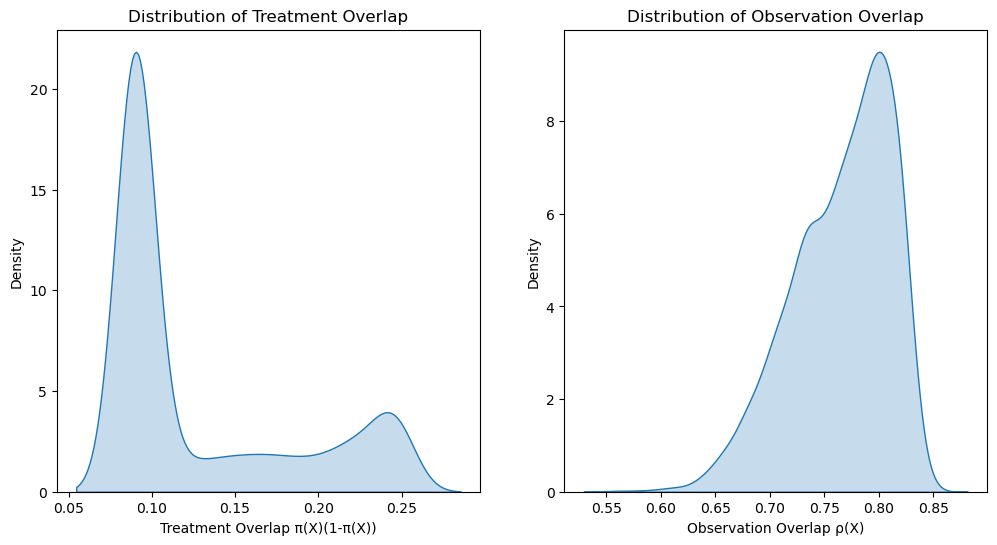

In [10]:
#plot distribution of t_overlap and o_overlap in horizontally splitted kde plots
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
sns.kdeplot(t_overlap, fill=True)
plt.xlabel('Treatment Overlap π(X)(1-π(X))')
plt.title('Distribution of Treatment Overlap')
plt.subplot(1, 2, 2)
sns.kdeplot(o_overlap, fill=True)
plt.xlabel('Observation Overlap ρ(X)')
plt.title('Distribution of Observation Overlap')